In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Integrated_Traffic_Weather_Hyderabad.csv")

# Quick check
df.head()

,DateTime,Junction,Vehicles,ID,Date,Hour,Temperature,Precipitation,WindSpeed,Humidity
0,2015-11-01 00:00:00,1,15,20151101001,2015-11-01,0,26.091101,0.001659,3.0,60.0
1,2015-11-01 01:00:00,1,13,20151101011,2015-11-01,1,26.091101,0.001659,3.0,60.0
2,2015-11-01 02:00:00,1,10,20151101021,2015-11-01,2,26.091101,0.001659,3.0,60.0
3,2015-11-01 03:00:00,1,7,20151101031,2015-11-01,3,26.091101,0.001659,3.0,60.0
4,2015-11-01 04:00:00,1,9,20151101041,2015-11-01,4,26.091101,0.001659,3.0,60.0


In [2]:
# Convert DateTime column to datetime format
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Sort data by time
df = df.sort_values('DateTime')

# Confirm
df[['DateTime']].head()

,DateTime
0,2015-11-01 00:00:00
14592,2015-11-01 00:00:00
29184,2015-11-01 00:00:00
29185,2015-11-01 01:00:00
1,2015-11-01 01:00:00


In [3]:
# Reset index after sorting
df = df.reset_index(drop=True)

df.head()

,DateTime,Junction,Vehicles,ID,Date,Hour,Temperature,Precipitation,WindSpeed,Humidity
0,2015-11-01 00:00:00,1,15,20151101001,2015-11-01,0,26.091101,0.001659,3.0,60.0
1,2015-11-01 00:00:00,2,6,20151101002,2015-11-01,0,26.100000,0.000000,3.0,60.0
2,2015-11-01 00:00:00,3,9,20151101003,2015-11-01,0,26.100000,0.000000,3.0,60.0
3,2015-11-01 01:00:00,3,7,20151101013,2015-11-01,1,26.100000,0.000000,3.0,60.0
4,2015-11-01 01:00:00,1,13,20151101011,2015-11-01,1,26.091101,0.001659,3.0,60.0


In [5]:
# Create time-based features
df['DayOfWeek'] = df['DateTime'].dt.dayofweek   # 0 = Monday
df['Month'] = df['DateTime'].dt.month
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Verify
df[['DateTime', 'DayOfWeek', 'Month', 'IsWeekend']].head()

,DateTime,DayOfWeek,Month,IsWeekend
0,2015-11-01 00:00:00,6,11,1
1,2015-11-01 00:00:00,6,11,1
2,2015-11-01 00:00:00,6,11,1
3,2015-11-01 01:00:00,6,11,1
4,2015-11-01 01:00:00,6,11,1


In [6]:
# Target variable
y = df['Vehicles']

# Feature columns
feature_cols = [
    'Hour',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'Temperature',
    'Precipitation',
    'WindSpeed',
    'Humidity'
]

X = df[feature_cols]

X.head(), y.head()

(   Hour  DayOfWeek  Month  IsWeekend  Temperature  Precipitation  WindSpeed  \
 0     0          6     11          1    26.091101       0.001659        3.0   
 1     0          6     11          1    26.100000       0.000000        3.0   
 2     0          6     11          1    26.100000       0.000000        3.0   
 3     1          6     11          1    26.100000       0.000000        3.0   
 4     1          6     11          1    26.091101       0.001659        3.0   
 
    Humidity  
 0      60.0  
 1      60.0  
 2      60.0  
 3      60.0  
 4      60.0  ,
 0    15
 1     6
 2     9
 3     7
 4    13
 Name: Vehicles, dtype: int64)

In [7]:
# Time-based split (80% train, 20% validation)
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_val   = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_val   = y.iloc[split_index:]

X_train.shape, X_val.shape

((38496, 8), (9624, 8))

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize model
lr = LinearRegression()

# Train model
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_val)

# Evaluation metrics
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

mae, rmse, r2

(18.521284434881622, np.float64(27.454212061793054), -0.016927559205220932)

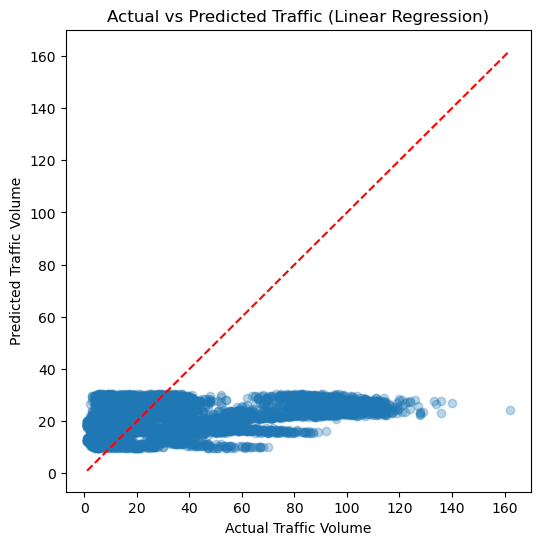

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--')

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted Traffic (Linear Regression)")
plt.show()

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_val)

# Metrics
mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

(mae_rf, rmse_rf, r2_rf)

(18.174332145431745, np.float64(27.518909064452664), -0.021726071422796478)

In [11]:
df['Vehicles_lag_1'] = df.groupby('Junction')['Vehicles'].shift(1)
df = df.dropna()

In [13]:
#Update feature list
feature_cols = [
    'Hour',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'Temperature',
    'Precipitation',
    'WindSpeed',
    'Humidity',
    'Vehicles_lag_1'
]

In [14]:
#Recreate X and y
X = df[feature_cols]
y = df['Vehicles']

In [15]:
#Redo time-based split
split_idx = int(len(df) * 0.8)

X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

In [17]:
#Retrain Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

In [18]:
#Recompute metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_val, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2 = r2_score(y_val, y_pred_rf)

(mae, rmse, r2)

(3.747222644796671, np.float64(5.699597044052365), 0.9561711218710675)

## Final Model Selection

After experimenting with Linear Regression and Random Forest models,
Random Forest with a one-hour lag feature was selected as the final model.

This model demonstrated significantly better performance, capturing
temporal traffic patterns effectively while maintaining strong generalization.

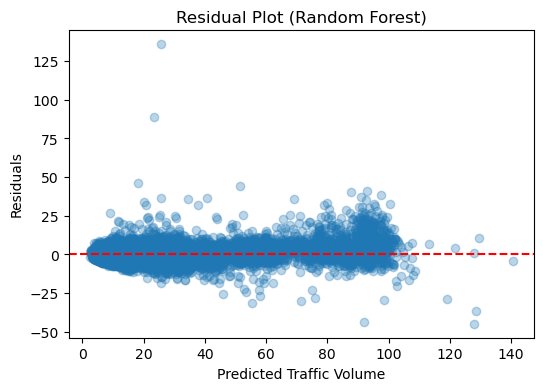

In [20]:
# Residuals
residuals = y_val - y_pred_rf

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_pred_rf, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")
plt.show()

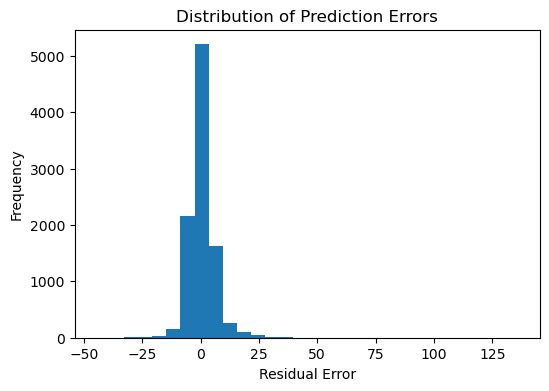

In [21]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()

In [22]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []

for train_idx, val_idx in tscv.split(X):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    rf.fit(X_train_cv, y_train_cv)
    preds = rf.predict(X_val_cv)
    mae_scores.append(mean_absolute_error(y_val_cv, preds))

np.mean(mae_scores), mae_scores

(np.float64(3.4825404448205872),
 [2.9282922184396787,
  3.4816387534801945,
  3.587553809821064,
  3.7362344375534615,
  3.67898300480854])

## Model Refinement

Initial models showed underfitting due to the absence of temporal features.
Introducing a one-hour lag of traffic volume significantly improved model
performance.

Further lag features were evaluated but not included, as the first lag
captured the dominant temporal dependency while additional lags increased
model complexity without meaningful performance gains.